In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot
from freealg.visualization._api_plot_util import _decimal_text, _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'Umatrix64k'
latex = True

# Diffusion Model

Data's ESD replicates Fig 4 (right panel) of:

* [Why Diffusion Models Don’t Memorize: The Role of Implicit Dynamical Regularization in Training](https://openreview.net/pdf?id=BSZqpqgqM0)

The data is the matrix $\mathbf{U}$ in the above paper, here generated at the size $64K \times 64K$.

The input file loaded below (`Umatrix64k_eigs.npz`) contains a list of numpy arrays. Each array is the eigenvalues of a sumbatrix, ranging from the size $1K, 2K, 4K, \dots, 64K$.

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000
6    64000



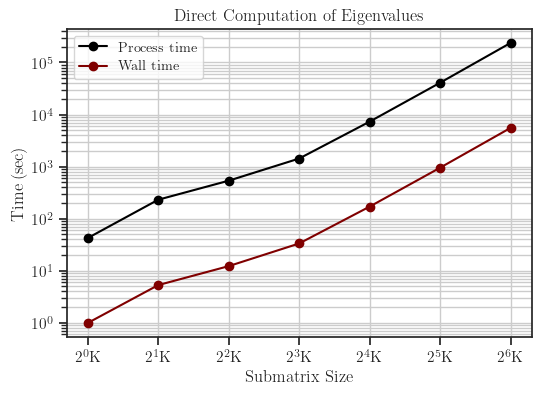

In [2]:
# Load input file
filename = 'Umatrix64k_eigs.npz'
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

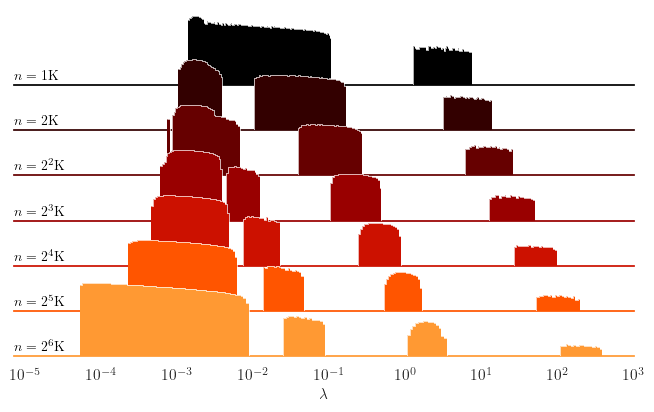

In [20]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

# Fit Spectral Curve

In [3]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 2

# Detect support from histogram
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 4,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=support,
                   # support=None,
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# deg_m, deg_z = 8, 2
# deg_m, deg_z = 7, 3
deg_m, deg_z = 6, 3

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r=[1.8, 5],
    n_r=[1, 1],
    n_samples=4096,
    # y_eps=1e-5,
    y_eps=1e-4,
    # x_pad=0.0,
    normalize=True, triangular=None,
    # mu='auto',
    mu=None,
    mu_reg=None, verbose=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0007,    0.0064)
	Interval 2: (   0.0377,    0.2727)
	Interval 3: (   6.1221,   27.0271)

------------------------------------------
fit residual max  : 3.6216e-03
fit residual 99.9%: 5.4900e-04

Coefficients (real)
+0.99121788 -0.11502649 -0.01358533 +0.00024553 -0.00000072 +0.00000000 +0.00000000 
-0.00836343 +2.68844301 -0.22067498 -0.03300354 +0.00049345 -0.00000067 -0.00000000 
-0.00041869 -0.03244948 +2.26624349 -0.10057827 -0.01979050 +0.00023804 +0.00000006 
+0.00000000 -0.00041840 -0.02424967 +0.56530237 +0.00194836 -0.00001023 +0.00000001 

Coefficients (imag) norm: 0.0000e+00


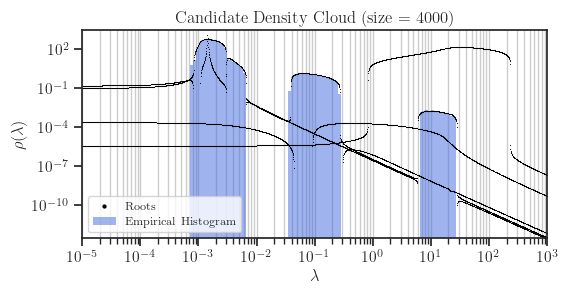

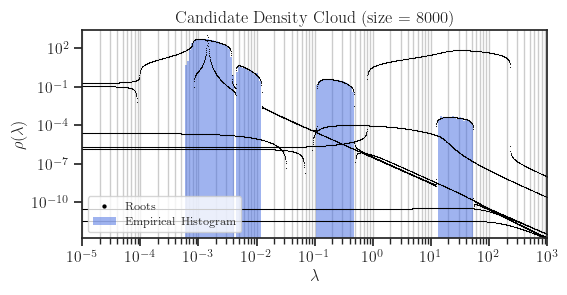

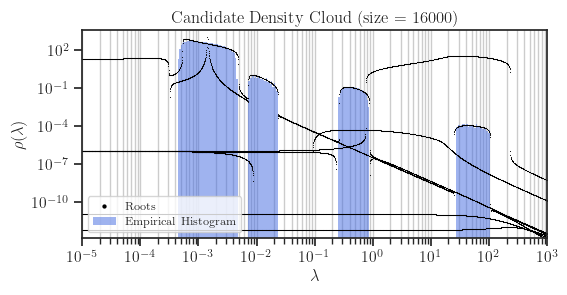

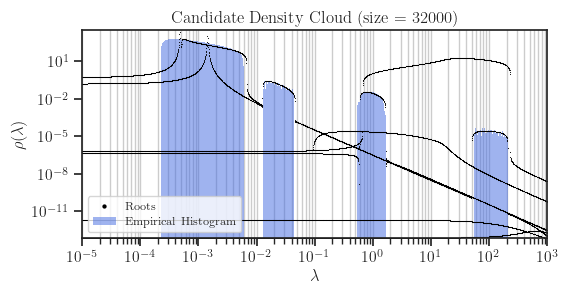

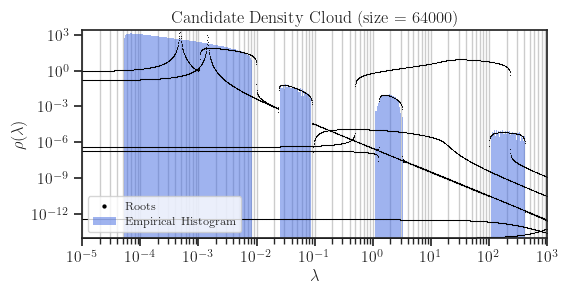

In [4]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 2000)

for idx in range(start_idx, sizes.size):
    af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

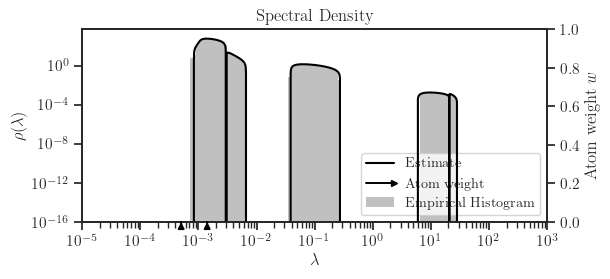


Mass: 1.00100662


In [4]:
# Plot density
x_min = 1e-5
x_max = 1e3
x0 = numpy.geomspace(x_min, x_max, 2000)
rho0 = af.density(x0, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x0)
print(f'Mass: {mass:0.8f}')

Support (estimated from polynomial):
	Interval 1: (   0.0009,    0.0030)
	Interval 2: (   0.0031,    0.0063)
	Interval 3: (   0.0388,    0.2728)
	Interval 4: (   5.9053,   19.9720)
	Interval 5: (  19.9720,   20.6208)
	Interval 6: (  20.6208,   28.2615)


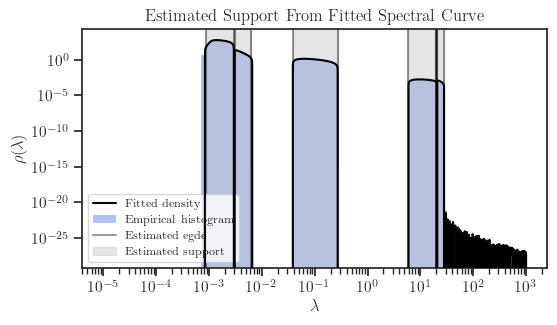

In [5]:
print('Support (estimated from polynomial):')

est_supp = af.support()

for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

with texplot.theme(use_latex=latex):
    alpha = 0.4
    fig, ax = plt.subplots(figsize=(6, 3.1))
    ax.plot(x0, rho0, color='black', zorder=10, label='Fitted density')
    
    bins = numpy.geomspace(
        numpy.min(eigs[start_idx]), numpy.max(eigs[start_idx]), 150)
    ax.hist(eigs[start_idx], bins, density=True,color='royalblue',
            alpha=0.4, zorder=1, edgecolor='none',
            label='Empirical histogram')
    
    for i in range(len(est_supp)):
        label = 'Estimated egde' if i == 0 else ''
        ax.axvline(est_supp[i][0], linestyle='-', color='black', alpha=alpha, label=label)
        ax.axvline(est_supp[i][1], linestyle='-', color='black', alpha=alpha)
    
        label = 'Estimated support' if i == 0 else ''
        ax.axvspan(est_supp[i][0], est_supp[i][1], color='silver', alpha=alpha, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim([x[0], x[-1]])
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\rho(\lambda)$')
    ax.legend(fontsize='x-small', loc='lower left')
    ax.set_title('Estimated Support From Fitted Spectral Curve')
    plt.show()

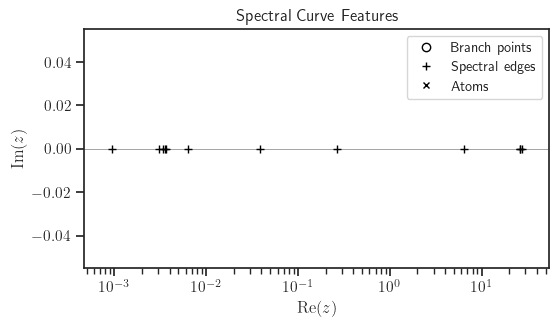


i   Branch Points        Spectral Edge
--  -------------------  -------------


In [23]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

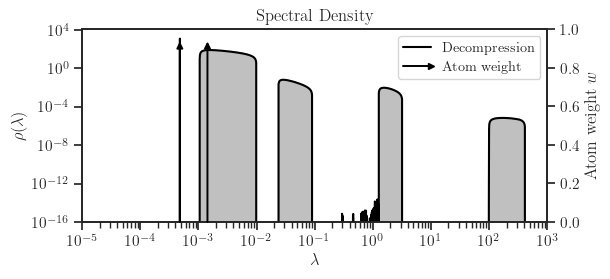

In [6]:
# Choosing the largest sub-matrix size to decompress to
# end_idx = sizes.size - 1
end_idx = 6

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 2000)

newton_opt = dict(
    dt_max=0.01,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=10,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/Umatrix64k-flow.pdf".


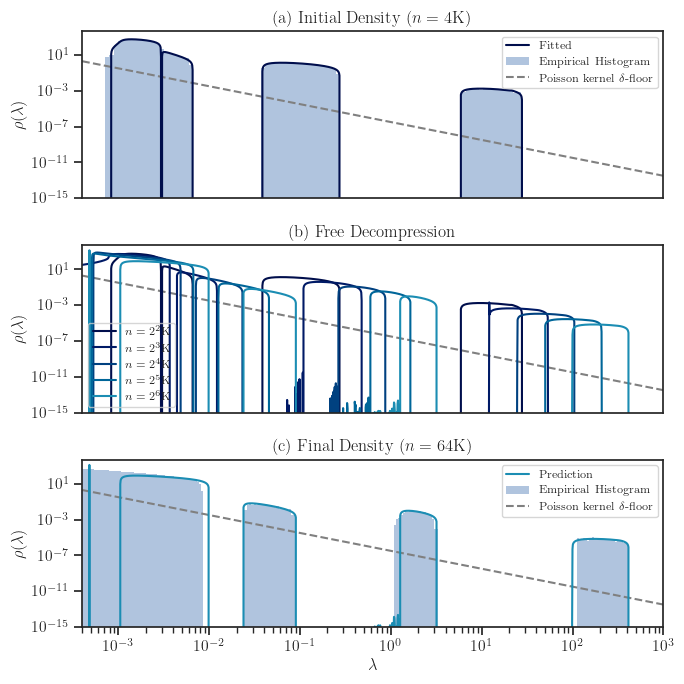

In [12]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          xlim=(4e-4, 1e3),
          ylim=(1e-15, 5e3),
          # ylim=(1e-8, 5e3),
          nbins=(100, 300),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.7),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=latex,
          save=join(plot_dir, save_filename + '-flow.pdf'))

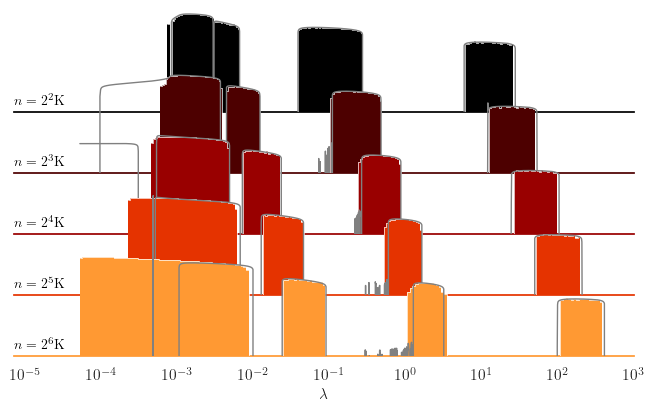

In [13]:
mask = x > numpy.min(eigs[end_idx])
ridgeplot(sizes[start_idx:end_idx+1], x=x[mask], rho=rho[:, mask],
          eigs=eigs[start_idx:end_idx+1],
          log=True, scaley=False, hspace=-0.4, rho_color='gray',
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

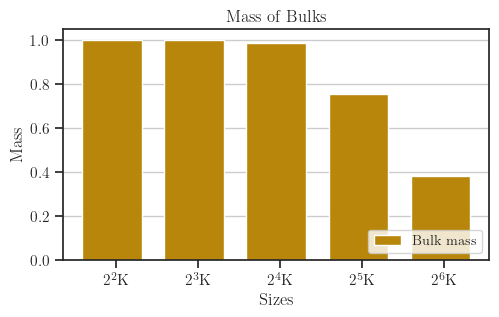

In [14]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, latex=latex,
          save=False)

In [7]:
t_cusp = numpy.linspace(0, 4, 100)
cusps = af.cusp(t_cusp)

print('Cusps:')
for cusp in cusps:
    x_cusp, t_cusp = cusp
    print(f'\tx: {x_cusp:>0.3f}, t: {t_cusp:>0.3f}')

if len(cusps) > 0:
    x_cusp, t_cusp = cusps[0]
else:
    x_cusp, t_cusp = None, None

Cusps:


In [6]:
end_idx = 6
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(sizes[end_idx] / sizes[start_idx])
t = numpy.linspace(0, t_final, 50)

complex_edges, real_merged_edges, active_k = af.edge(t)

In [7]:
from matplotlib.collections import PolyCollection

# ===========
# fill  bulks
# ===========

def fill_bulks(ax, t, edges, color, alpha=0.05, zorder=-2, width_tol=1e-12):
    """
    Seam-free fill for multiple bulks, generic 2k-column edges.
    Works as long as the number of *active bulks* does not change between
    consecutive time samples. (Insert cusp times into t to ensure that.)
    """
    t = numpy.asarray(t, dtype=float)
    E = numpy.asarray(edges, dtype=float)

    polys = []

    def add_strip(y0, y1, xL0, xR0, xL1, xR1):
        if not (numpy.isfinite(xL0) and numpy.isfinite(xR0) and numpy.isfinite(xL1) and numpy.isfinite(xR1)):
            return
        if (xR0 - xL0) <= width_tol or (xR1 - xL1) <= width_tol:
            return
        polys.append([(xL0, y0), (xR0, y0), (xR1, y1), (xL1, y1)])

    for i in range(len(t) - 1):
        e0 = E[i, :]
        e1 = E[i + 1, :]

        f0 = e0[numpy.isfinite(e0)]
        f1 = e1[numpy.isfinite(e1)]

        # Need complete pairs
        if (len(f0) % 2) != 0 or (len(f1) % 2) != 0:
            continue

        # If bulks count changes inside this step, skip (avoid wrong pairing)
        if len(f0) != len(f1):
            continue

        f0 = numpy.sort(f0)
        f1 = numpy.sort(f1)

        y0 = t[i]
        y1 = t[i + 1]

        nb = len(f0) // 2
        for j in range(nb):
            xL0, xR0 = f0[2*j], f0[2*j + 1]
            xL1, xR1 = f1[2*j], f1[2*j + 1]
            add_strip(y0, y1, xL0, xR0, xL1, xR1)

    if not polys:
        return

    coll = PolyCollection(
        polys,
        facecolors=[color],
        edgecolors="none",
        closed=True,
        alpha=alpha,
        zorder=zorder)

    ax.add_collection(coll)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/Umatrix64k-edge.pdf".


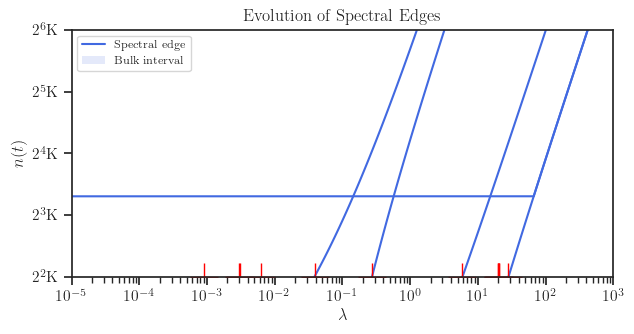

In [8]:
import matplotlib

# =============
# plot annotate
# =============

def plot_edges(complex_edges, real_merged_edges, sizes=None, edge_color='royalblue',
               alpha=0.1, fill_color='royal_blue', figsize=None, annotate=False, xlim=None, log=False,
               flip_y=False):
    """
    """
    
    # k = len(support)
    k = real_merged_edges.shape[1] // 2
    
    with texplot.theme(use_latex=True):

        if figsize is None:
            figsize = (6.5, 3.5)
            
        fig, ax = plt.subplots(figsize=figsize)
                               
        for j in range(k):
            a_r = real_merged_edges[:, 2*j + 0]
            b_r = real_merged_edges[:, 2*j + 1]
    
            a_c = complex_edges[:, 2*j + 0].real
            b_c = complex_edges[:, 2*j + 1].real

            if sizes is None:
                t_ = t
            else:
                t_ = sizes[0] * numpy.exp(t)
            
            # Plot spectral edges with solid lines
            label = 'Spectral edge' if j == 0 else ''
            ax.plot(a_r, t_, color=edge_color, label=label)
            ax.plot(b_r, t_, color=edge_color)
    
            # Plot ghost edges with dashed lines
            # m_a = numpy.isnan(a_r)
            # m_b = numpy.isnan(b_r)
            # ax.plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
            # ax.plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)
    
            # Fill between (does not work with bifurcation, use fill_split_bulk)
            # ax.fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)
            
            # --------
            # Plot I_j
            # --------
    
            if annotate:
                t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.75 * t[-1]
                # t_mid = 0.8 * t[-1]
                j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
                
                ax.annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
                
                ax.text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                        fr'$I_{{{j+1}}}(t)$',
                        color='gray', ha='center', va='bottom', fontsize=11)
    
        # Fill between edges includign the bifurcated egdes # TEST
        # fill_bulks(ax, t_, real_merged_edges, color=fill_color, alpha=alpha, zorder=-2)
    
        # ----------------
        # Plot I_1 cup I_2
        # ----------------
    
        if annotate:
            a_all = real_merged_edges[:, 0]
            b_all = real_merged_edges[:, -1]
        
            t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
            j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
            
            ax.annotate('', xy=(b_all[j_mid2], t[j_mid2]), xytext=(a_all[j_mid2], t[j_mid2]),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
            
            ax.text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
                    # r'$I_1(t) \cup I_2(t)$',
                    r'$I(t), \quad t < t_{\ast}$',
                    color='gray', ha='center', va='bottom', fontsize=11)

        # ---------------------
        # Initial edges
        if af.est_supp is not None:
            for edge_a, edge_b in af.est_supp:
                plt.plot(edge_a, t_[0], '+', color='red', markersize=20)
                plt.plot(edge_b, t_[0], '+', color='red', markersize=20)
    
        # ---------------------
    
        # Cusp
        if (annotate is True) and ('t_cusp' in globals()):
            ax.plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
            ax.text(x_cusp + 0.12, t_cusp - 0.05, r'$(x_{\ast}, t_{\ast})$', fontsize=11)
    
        ax.set_xlim([x_min, x_max])
        ax.set_ylim([t_[0], t_[-1]])
        ax.set_xlabel(r'$\lambda$')
        ax.set_title(r'Evolution of Spectral Edges')
        
        h, l = ax.get_legend_handles_labels()
        h.append(matplotlib.patches.Patch(
            facecolor=fill_color, alpha=alpha, edgecolor='none'))
        l.append('Bulk interval')
        ax.legend(h, l, fontsize='x-small')

        if sizes is not None:
            ax.set_ylabel(r'$n(t)$')
        else:
            ax.set_ylabel(r'$t$')

        if log:
            ax.set_xscale('log')

            if sizes is not None:
                ax.set_yscale('log', base=2)

        if sizes is not None:
            ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
            
        if xlim is not None:
            ax.set_xlim(xlim)

        if flip_y:
            ax.invert_yaxis()
        
        plt.tight_layout()
    
        save_full_filename = join(plot_dir, save_filename + '-edge.pdf')
        texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                                  transparent_background=True, dpi=200,
                                  show_and_save=True, verbose=True)

# ----------------

plot_edges(complex_edges, real_merged_edges, sizes=fd_sizes,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           # edge_color='black', fill_color='gray', alpha=0.2,
           figsize=None, annotate=False, xlim=(1e-5, 1e3), log=True,
           flip_y=False)

In [9]:
print("self.supp =", af.supp)
print("self.est_supp =", af.est_supp)
print("len(self.supp) =", None if af.supp is None else len(af.supp))
print("len(self.est_supp) =", None if af.est_supp is None else len(af.est_supp))

self.supp = [(0.0007179157176646985, 0.006427913719603937), (0.03765383487416814, 0.27269494648341963), (6.122066430914156, 27.02706865663607)]
self.est_supp = [(0.0008921320974294284, 0.002951726518668487), (0.003070695796625626, 0.006324814776889104), (0.03878090732457721, 0.27279349015994053), (5.905289851850127, 19.972021543128125), (19.972021543128125, 20.62077491639086), (20.62077491639086, 28.261511399693426)]
len(self.supp) = 3
len(self.est_supp) = 6


In [23]:
af.est_supp

[(0.0008807767366105077, 0.002974088163575854),
 (0.003025512170692908, 0.006337487695253449),
 (0.03878090732457721, 0.27306832161970895),
 (5.850692573864126, 28.08709926860469)]

In [11]:
numpy.log10(af.est_supp[0][0])

np.float64(-3.0551341646256662)

In [11]:
complex_edges.shape

(50, 6)

In [30]:
complex_edges[:, :].imag

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0.

In [31]:
complex_edges[:, :].real

array([[-1.91353086e-01, -1.94492429e-01,  3.84415929e-02,
         2.73067448e-01,  5.85069210e+00,  2.78326313e+01],
       [-8.56547836e+01, -9.00369600e+01,  4.21771256e-02,
         2.85226441e-01,  6.21473422e+00,  2.93466299e+01],
       [-2.74992715e+02, -2.74688263e+02,  4.61981792e-02,
         2.98033550e-01,  6.60002975e+00,  3.09478995e+01],
       [-2.74374218e+02, -2.74611793e+02,  5.05221322e-02,
         3.11526387e-01,  7.00781239e+00,  3.26415412e+01],
       [-2.67100980e+02, -2.67132127e+02,  5.51673483e-02,
         3.25744812e-01,  7.43938789e+00,  3.44329532e+01],
       [-2.60810050e+02, -2.60792759e+02,  6.01532313e-02,
         3.40731068e-01,  7.89613818e+00,  3.63278484e+01],
       [-2.56252234e+02, -2.56066774e+02,  6.55002824e-02,
         3.56529916e-01,  8.37952588e+00,  3.83322726e+01],
       [-2.51719838e+02, -2.51114866e+02,  7.12301615e-02,
         3.73188790e-01,  8.89109890e+00,  4.04526237e+01],
       [-2.45723819e+02, -2.45224749e+02,  7.736

In [20]:
complex_edges[-10:, :].real

array([[ 5.97938520e+01, -6.55837529e+02,  7.25190795e-01,
         1.96848168e+00,  5.97938520e+01,  2.50664120e+02],
       [ 6.32991470e+01, -6.93507792e+02,  7.71750183e-01,
         2.07741794e+00,  6.32991470e+01,  2.65130925e+02],
       [ 6.70085082e+01, -7.32132683e+02,  8.21078507e-01,
         2.19266956e+00,  6.70085082e+01,  2.80439738e+02],
       [ 7.09338151e+01, -7.73923701e+02,  8.73335617e-01,
         2.31460525e+00,  7.09338151e+01,  2.96639585e+02],
       [ 7.50876386e+01, -8.16111715e+02,  9.28690648e-01,
         2.44361519e+00,  7.50876386e+01,  3.13782346e+02],
       [ 7.94832816e+01, -8.63564364e+02,  9.87322556e-01,
         2.58011222e+00,  7.94832816e+01,  3.31922922e+02],
       [ 8.41348212e+01,  3.51119407e+02,  1.04942070e+00,
         2.72453320e+00,  8.41348212e+01,  3.51119407e+02],
       [ 8.90571541e+01,  3.71433277e+02,  1.11518544e+00,
         2.87734038e+00,  8.90571541e+01,  3.71433277e+02],
       [ 9.42660444e+01,  3.92929590e+02,  1.184

In [22]:
complex_edges[-10:, -1].real

array([250.66412028, 265.13092474, 280.43973752, 296.63958478,
       313.78234636, 331.92292188, 351.1194066 , 371.43327743,
       392.92958981, 415.67718606])